In [41]:
import pandas as pd

df = pd.read_csv("../data/processed/cota_2024_features.csv")

In [43]:
baseline = df["LapTimeSec"].mean()

baseline

100.18664099660249

In [45]:
driver_avg = df.groupby("Driver")["LapTimeSec"].mean()

driver_avg

Driver
ALB    101.119370
ALO    100.835522
BOT    101.462391
COL    100.249064
GAS    100.463213
HUL    100.029128
LAW    100.212128
LEC     98.942521
MAG    100.049089
NOR     99.204854
OCO    100.995767
PER    100.012128
PIA     99.307936
RUS     99.778625
SAI     99.119396
STR    101.138756
TSU    100.593696
VER     99.305333
ZHO    101.053045
Name: LapTimeSec, dtype: float64

In [47]:
driver_delta = driver_avg - baseline

driver_delta.sort_values()

Driver
LEC   -1.244120
SAI   -1.067245
NOR   -0.981787
VER   -0.881308
PIA   -0.878705
RUS   -0.408016
PER   -0.174513
HUL   -0.157513
MAG   -0.137552
LAW    0.025487
COL    0.062423
GAS    0.276572
TSU    0.407055
ALO    0.648881
OCO    0.809126
ZHO    0.866404
ALB    0.932729
STR    0.952115
BOT    1.275750
Name: LapTimeSec, dtype: float64

In [49]:
df["DriverPaceDelta"] = df["Driver"].map(driver_delta)

In [51]:
df["DriverCorrectedLap"] = df["LapTimeSec"] - df["DriverPaceDelta"]

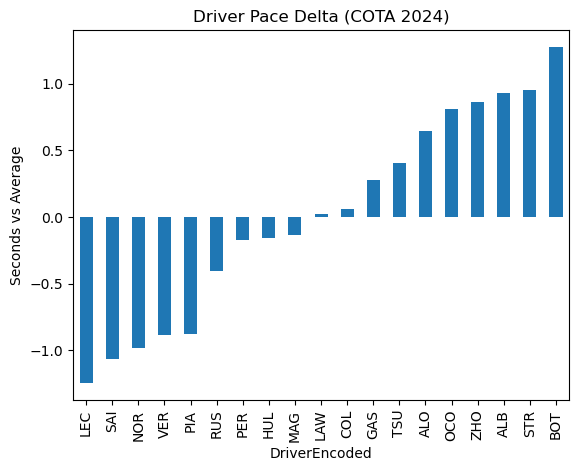

In [53]:
import matplotlib.pyplot as plt

driver_delta.sort_values().plot(kind="bar")

plt.title("Driver Pace Delta (COTA 2024)")
plt.ylabel("Seconds vs Average")
plt.xlabel("DriverEncoded")

plt.show()

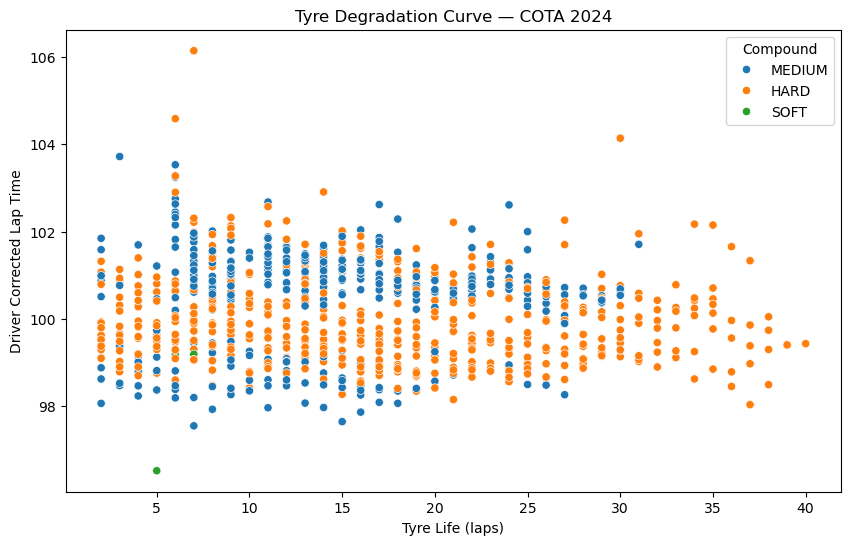

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="TyreLife",
    y="DriverCorrectedLap",
    hue="Compound"
)

plt.title("Tyre Degradation Curve — COTA 2024")
plt.xlabel("Tyre Life (laps)")
plt.ylabel("Driver Corrected Lap Time")

plt.show()

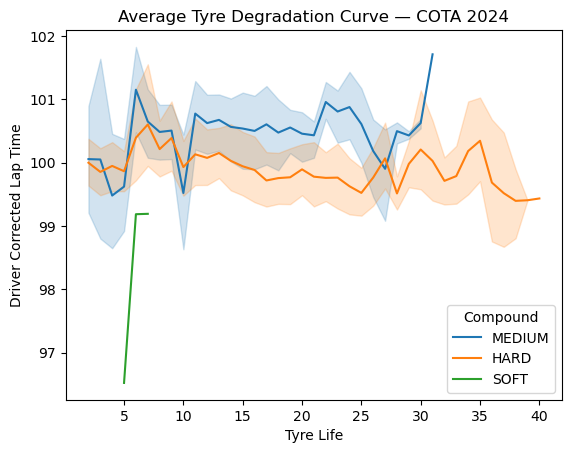

In [59]:
import seaborn as sns

sns.lineplot(
    data=df,
    x="TyreLife",
    y="DriverCorrectedLap",
    hue="Compound",
    estimator="mean"
)

plt.title("Average Tyre Degradation Curve — COTA 2024")
plt.xlabel("Tyre Life")
plt.ylabel("Driver Corrected Lap Time")

plt.show()